# Centrally Trained GRU Autoencoder — Metrics

Evaluate a model trained with `train_central.py`.

This notebook:
1. Loads the centrally trained checkpoint (`central.npz`) and its scaler (`central_scaler.npz`)
2. Loads held-out parquet telemetry and builds windows using the **saved** scaler
3. Injects synthetic attacks (spike / drift / frequency / splice)
4. Scores benign vs attack windows with the model's reconstruction error
5. Reports AUROC, F1 (at calibrated & optimal thresholds), precision/recall, confusion matrix
6. Plots score distributions, ROC curve, and per-attack AUROC

> Run from `Python scripts/mvp_v1/` so `fed_client_jax` is importable.
> Requires: `pip install numpy pandas pyarrow scikit-learn matplotlib paho-mqtt "jax[cpu]"`

## 1. Configuration

Point these at your checkpoint, scaler, and evaluation parquet data. Defaults match `train_central.py`.

In [1]:
from pathlib import Path

# Checkpoint + scaler produced by train_central.py (default CHECKPOINT_DIR is /tmp/fed_ids_checkpoints)
CKPT_PATH   = Path("/tmp/fed_ids_checkpoints/central.npz")
SCALER_PATH = Path("/tmp/fed_ids_checkpoints/central_scaler.npz")

# Parquet file or folder to evaluate on (ideally held out from training)
DATA_PATH = Path("../../Data/new_data_processed")

EVAL_STRIDE       = 20      # window stride (20 matches the live client)
MAX_EVAL_WINDOWS  = 20_000  # cap for speed (uniform subsample across trace)
ATTACK_RATE       = 0.30    # fraction of windows to corrupt with a synthetic attack
SEED              = 42

## 2. Imports & load the trained model

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax.numpy as jnp
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, confusion_matrix,
    average_precision_score, precision_recall_curve,
)

from fed_client_jax import (
    GRUAutoencoder,
    WINDOW_SIZE,
    N_FEATURES,
    ANOMALY_PERCENTILE,
    ANOMALY_SAFETY_MULT,
)

np.random.seed(SEED)
rng = np.random.default_rng(SEED)

# Build the model and load weights + threshold directly from the npz
# (avoids depending on the module CHECKPOINT_DIR / name).
model = GRUAutoencoder(seed=SEED)
ckpt = np.load(CKPT_PATH)
model.params = {k: jnp.array(ckpt[k].astype(np.float32)) for k in model._WEIGHT_KEYS}
model.threshold = float(ckpt["threshold"][0])
model.calibrated = bool(ckpt["calibrated"][0])

scaler = np.load(SCALER_PATH)
MU, SD = scaler["mean"].astype(np.float32), scaler["std"].astype(np.float32)

print(f"Loaded checkpoint: {CKPT_PATH}")
print(f"  calibrated : {model.calibrated}")
print(f"  threshold  : {model.threshold:.6f}")
print(f"  scaler mean: {np.round(MU, 3)}")
print(f"  scaler std : {np.round(SD, 3)}")

[Model] Warming up JIT compilation...
[Model] JIT warmup complete
Loaded checkpoint: /tmp/fed_ids_checkpoints/central.npz
  calibrated : True
  threshold  : 0.681577
  scaler mean: [ 2.0265e+01  5.5476e+01  3.3700e-01  2.5000e-01 -1.3000e-02  1.4240e+00
  1.8423e+01  3.6634e+01]
  scaler std : [1.2147e+01 2.6900e+01 2.5700e-01 4.3000e-01 3.7000e-02 5.8400e-01
 8.8629e+01 7.1465e+01]


## 3. Load parquet & build windows (using the saved scaler)

We normalise with the **training** mean/std so the calibrated threshold stays valid.

In [3]:
FEATURES = ("speed_kmh", "battery_level", "throttle", "brake",
            "steering", "gear", "location_x", "location_y")

ALIASES = {
    "speed_kmh":     ("speed_kmh", "speed", "velocity"),
    "battery_level": ("battery_level", "battery", "soc"),
    "throttle":      ("throttle", "throttle_pct"),
    "brake":         ("brake", "brake_pct"),
    "steering":      ("steering", "steer", "steering_angle"),
    "gear":          ("gear", "current_gear"),
    "location_x":    ("location_x", "loc_x", "pos_x", "x"),
    "location_y":    ("location_y", "loc_y", "pos_y", "y"),
}

def load_parquet(path: Path) -> np.ndarray:
    files = sorted(path.rglob("*.parquet")) if path.is_dir() else [path]
    if not files:
        raise FileNotFoundError(f"No parquet files at {path}")
    df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
    print(f"[Data] loaded {len(df):,} rows from {len(files)} file(s)")
    cols_lower = {c.lower(): c for c in df.columns}
    chosen = {}
    for canonical in FEATURES:
        for alias in ALIASES[canonical]:
            if alias.lower() in cols_lower:
                chosen[canonical] = cols_lower[alias.lower()]
                break
        else:
            raise KeyError(f"Missing feature {canonical!r}. Have: {list(df.columns)}")
    arr = df[[chosen[c] for c in FEATURES]].to_numpy(dtype=np.float32)
    return np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)

def to_windows(trace: np.ndarray, mu, sd, stride: int) -> np.ndarray:
    norm = ((trace - mu) / sd).astype(np.float32)
    idxs = range(0, len(norm) - WINDOW_SIZE + 1, stride)
    return np.stack([norm[i:i + WINDOW_SIZE].flatten() for i in idxs])

trace = load_parquet(DATA_PATH)
windows = to_windows(trace, MU, SD, EVAL_STRIDE)
print(f"[Windows] {len(windows):,} (stride={EVAL_STRIDE})")

if len(windows) > MAX_EVAL_WINDOWS:
    idx = np.linspace(0, len(windows) - 1, MAX_EVAL_WINDOWS, dtype=int)
    windows = windows[idx]
    print(f"[Windows] subsampled to {len(windows):,}")

[Data] loaded 3,160,814 rows from 103 file(s)
[Windows] 158,040 (stride=20)
[Windows] subsampled to 20,000


## 4. Inject synthetic attacks

Attacks operate on z-scored windows; magnitudes are in standard deviations — same definitions as `evaluate_mvp.py`.

In [4]:
def attack_spike(w, rng, magnitude=8.0):
    s = w.reshape(WINDOW_SIZE, N_FEATURES).copy()
    s[rng.integers(WINDOW_SIZE), rng.integers(N_FEATURES)] += magnitude
    return s.flatten()

def attack_drift(w, rng, magnitude=3.0):
    s = w.reshape(WINDOW_SIZE, N_FEATURES).copy()
    half = WINDOW_SIZE // 2
    s[half:, 0] += np.linspace(0, magnitude, WINDOW_SIZE - half, dtype=np.float32)
    return s.flatten()

def attack_frequency(w, rng, amplitude=2.0):
    s = w.reshape(WINDOW_SIZE, N_FEATURES).copy()
    s[:, 4] = amplitude * np.sin(np.pi * np.arange(WINDOW_SIZE, dtype=np.float32))
    return s.flatten()

def attack_splice(w_a, w_b, rng):
    a = w_a.reshape(WINDOW_SIZE, N_FEATURES).copy()
    b = w_b.reshape(WINDOW_SIZE, N_FEATURES)
    a[WINDOW_SIZE // 2:] = b[WINDOW_SIZE // 2:]
    return a.flatten()

ATTACKS = {"spike": attack_spike, "drift": attack_drift,
           "frequency": attack_frequency, "splice": attack_splice}

test_w = windows.copy()
labels = np.zeros(len(test_w), dtype=int)
kinds = np.array(["benign"] * len(test_w), dtype=object)

n_atk = int(len(test_w) * ATTACK_RATE)
atk_idx = rng.choice(len(test_w), n_atk, replace=False)
families = list(ATTACKS)
for j, i in enumerate(atk_idx):
    k = families[j % len(families)]
    if k == "splice":
        donor = windows[(i + len(test_w) // 2) % len(test_w)]
        test_w[i] = ATTACKS[k](windows[i], donor, rng)
    else:
        test_w[i] = ATTACKS[k](windows[i], rng)
    labels[i] = 1
    kinds[i] = k

print("[Attacks] " + ", ".join(f"{k}={int((kinds == k).sum())}" for k in families))
print(f"[Test] benign={int((labels == 0).sum()):,}  attack={int((labels == 1).sum()):,}")

[Attacks] spike=1500, drift=1500, frequency=1500, splice=1500
[Test] benign=14,000  attack=6,000


## 5. Score every window

The anomaly score is the model's per-window reconstruction MSE.

In [5]:
import time

scores = np.empty(len(test_w), dtype=np.float32)
lat_us = np.empty(len(test_w), dtype=np.float32)
for i, w in enumerate(test_w):
    t0 = time.perf_counter()
    scores[i] = model.reconstruction_error(w)
    lat_us[i] = (time.perf_counter() - t0) * 1e6

print(f"scored {len(scores):,} windows")
print(f"latency p50={np.percentile(lat_us,50):.1f}µs  p99={np.percentile(lat_us,99):.1f}µs")

scored 20,000 windows
latency p50=57.2µs  p99=67.1µs


## 6. Headline metrics

In [6]:
def best_threshold(scores, labels):
    cands = np.unique(np.percentile(scores, np.linspace(50, 99.9, 200)))
    best = (float(np.median(scores)), 0.0, 0.0, 0.0)
    for t in cands:
        pred = (scores > t).astype(int)
        tp = int(((pred == 1) & (labels == 1)).sum())
        fp = int(((pred == 1) & (labels == 0)).sum())
        fn = int(((pred == 0) & (labels == 1)).sum())
        if tp == 0:
            continue
        prec = tp / (tp + fp)
        rec = tp / (tp + fn)
        f1 = 2 * prec * rec / (prec + rec)
        if f1 > best[1]:
            best = (float(t), f1, prec, rec)
    return best

thr = model.threshold
pred = (scores > thr).astype(int)

auroc = roc_auc_score(labels, scores)
pr_auc = average_precision_score(labels, scores)   # PR AUC (average precision)
baseline_ap = float(labels.mean())                 # random-classifier PR AUC = prevalence
f1_cal = f1_score(labels, pred, zero_division=0)
recall_cal = float(pred[labels == 1].mean())
fpr_cal = float(pred[labels == 0].mean())
bt, bf1, bp, br = best_threshold(scores, labels)

print(f"overall AUROC              : {auroc:.3f}")
print(f"overall PR AUC (AP)        : {pr_auc:.3f}  (random baseline = {baseline_ap:.3f})")
print(f"@ calibrated thr {thr:.4f} : F1={f1_cal:.3f}  recall={recall_cal:.3f}  FPR={fpr_cal:.3f}")
print(f"@ optimal    thr {bt:.4f} : F1={bf1:.3f}  precision={bp:.3f}  recall={br:.3f}")

summary = pd.DataFrame({
    "metric": ["AUROC", "PR AUC (AP)", "F1 (calibrated)", "F1 (optimal)",
               "recall (calibrated)", "FPR (calibrated)",
               "latency p50 (µs)", "latency p99 (µs)"],
    "value": [auroc, pr_auc, f1_cal, bf1, recall_cal, fpr_cal,
              float(np.percentile(lat_us, 50)), float(np.percentile(lat_us, 99))],
})
summary.round(3)

overall AUROC              : 0.840
overall PR AUC (AP)        : 0.799  (random baseline = 0.300)
@ calibrated thr 0.6816 : F1=0.250  recall=0.144  FPR=0.004
@ optimal    thr 0.2358 : F1=0.804  precision=0.906  recall=0.722


,metric,value
0,AUROC,0.840
1,PR AUC (AP),0.799
2,F1 (calibrated),0.250
3,F1 (optimal),0.804
4,recall (calibrated),0.144
5,FPR (calibrated),0.004
6,latency p50 (µs),57.208
7,latency p99 (µs),67.125


### Confusion matrix (at calibrated threshold)

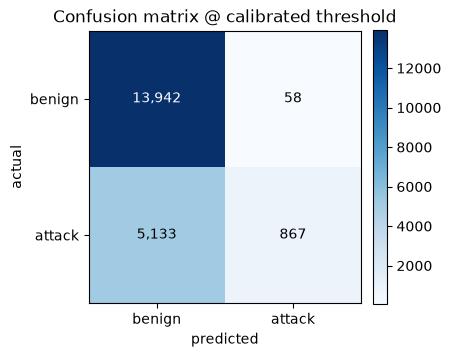

In [7]:
cm = confusion_matrix(labels, pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], ["benign", "attack"])
ax.set_yticks([0, 1], ["benign", "attack"])
ax.set_xlabel("predicted")
ax.set_ylabel("actual")
ax.set_title("Confusion matrix @ calibrated threshold")
for (r, c), v in np.ndenumerate(cm):
    ax.text(c, r, f"{v:,}", ha="center", va="center",
            color="white" if v > cm.max() / 2 else "black")
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 7. Score distributions (benign vs attack)

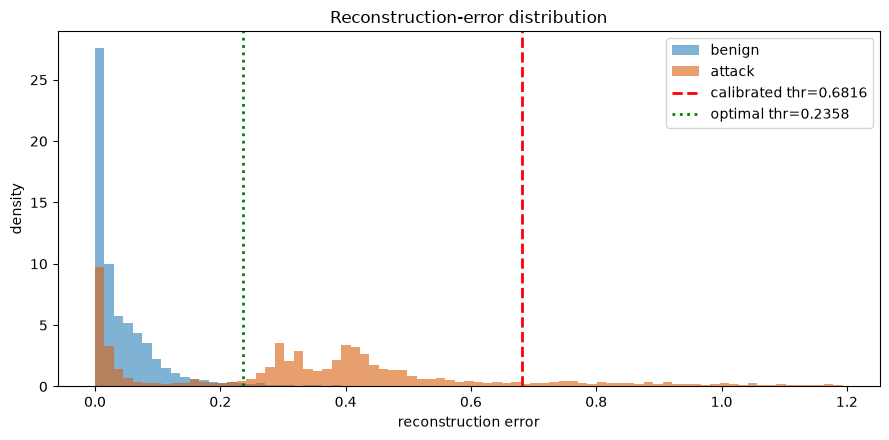

In [8]:
benign = scores[labels == 0]
attack = scores[labels == 1]

hi = np.percentile(scores, 99)
bins = np.linspace(0, hi, 80)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(benign, bins=bins, alpha=0.6, label="benign", color="#2c7fb8", density=True)
ax.hist(attack, bins=bins, alpha=0.6, label="attack", color="#d95f0e", density=True)
ax.axvline(thr, color="red", ls="--", lw=2, label=f"calibrated thr={thr:.4f}")
ax.axvline(bt, color="green", ls=":", lw=2, label=f"optimal thr={bt:.4f}")
ax.set_xlabel("reconstruction error")
ax.set_ylabel("density")
ax.set_title("Reconstruction-error distribution")
ax.legend()
plt.tight_layout()
plt.show()

## 8. ROC curve

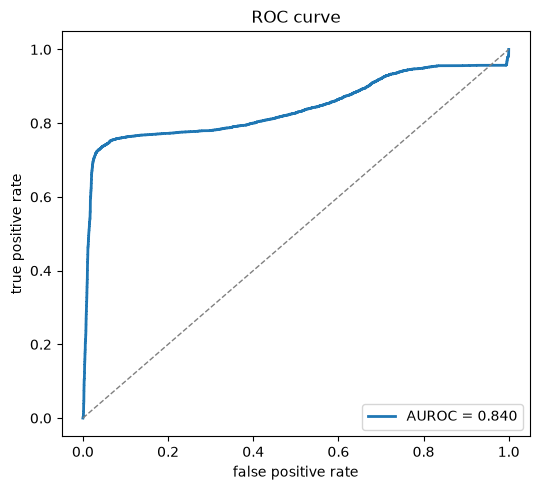

In [9]:
fpr, tpr, _ = roc_curve(labels, scores)
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, lw=2, label=f"AUROC = {auroc:.3f}")
ax.plot([0, 1], [0, 1], ls="--", color="gray", lw=1)
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("ROC curve")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 8b. Precision–Recall curve

PR AUC (average precision) is more informative than ROC AUC when attacks are rare — the random baseline equals the attack prevalence.

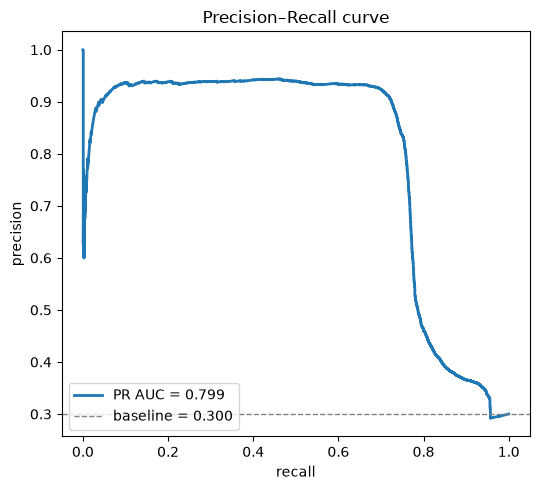

In [10]:
prec_curve, rec_curve, _ = precision_recall_curve(labels, scores)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(rec_curve, prec_curve, lw=2, label=f"PR AUC = {pr_auc:.3f}")
ax.axhline(baseline_ap, ls="--", color="gray", lw=1,
           label=f"baseline = {baseline_ap:.3f}")
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title("Precision–Recall curve")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## 9. Per-attack AUROC (each family vs benign)

Threshold-independent — shows whether the model *ranks* each attack type above benign traffic.

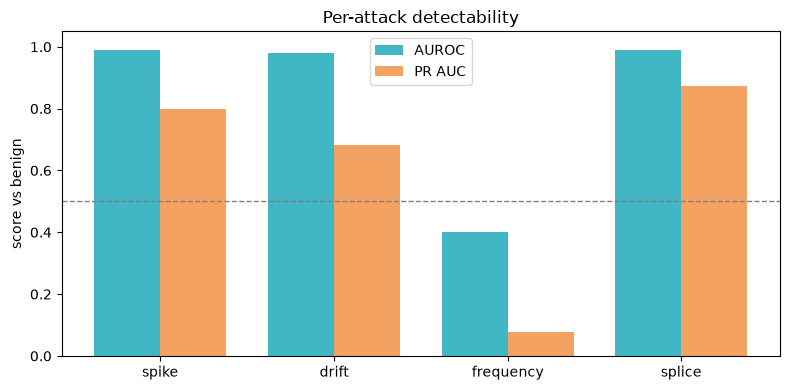

,attack,AUROC,PR_AUC,recall@calibrated
0,spike,0.991,0.800,0.023
1,drift,0.980,0.681,0.012
2,frequency,0.400,0.077,0.003
3,splice,0.988,0.874,0.539


In [11]:
rows = []
for k in ATTACKS:
    m = (kinds == k) & (labels == 1)
    if m.any():
        y = np.concatenate([np.zeros(len(benign)), np.ones(m.sum())])
        s = np.concatenate([benign, scores[m]])
        rows.append((k,
                     roc_auc_score(y, s),
                     average_precision_score(y, s),
                     float((scores[m] > thr).mean())))
per_attack = pd.DataFrame(
    rows, columns=["attack", "AUROC", "PR_AUC", "recall@calibrated"])

x = np.arange(len(per_attack))
width = 0.38
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width / 2, per_attack["AUROC"], width, label="AUROC", color="#41b6c4")
ax.bar(x + width / 2, per_attack["PR_AUC"], width, label="PR AUC", color="#f4a261")
ax.axhline(0.5, color="gray", ls="--", lw=1)
ax.set_xticks(x, per_attack["attack"])
ax.set_ylim(0, 1.05)
ax.set_ylabel("score vs benign")
ax.set_title("Per-attack detectability")
ax.legend()
plt.tight_layout()
plt.show()

per_attack.round(3)

## 10. Reading the results

- **AUROC** and **F1 @ optimal** show what the model *can* do (model quality).
- **F1 @ calibrated** shows what it *does* at the deployed threshold (p99 × 1.5).
- If F1@optimal ≫ F1@calibrated, the **threshold** is the bottleneck, not the model — recalibrate.
- Per-attack AUROC near 0.5 means that attack family is effectively invisible to the model.